The objective of this project is to analyze retail sales performance to identify revenue drivers, seasonal trends, product performance, and profitability insights that can support business decision-making.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("sales_data.csv")
df.columns = df.columns.str.strip()

# Convert dates
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Remove duplicates
df = df.drop_duplicates()

# Check missing values
missing = df.isnull().sum()
print("Missing Values:\n", missing)

# Create Year, Month, Quarter
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month_Name"] = df["Order Date"].dt.month_name()
df["Quarter"] = df["Order Date"].dt.quarter


Missing Values:
 Order ID            0
Order Date          0
Customer Name       0
Gender              0
Age                 0
Product             0
Region              0
City                0
Quantity            0
Unit Price          0
Discount (%)        0
Sales Channel       0
Customer Segment    0
Order Status        0
Category            0
Sub-Category        0
Revenue             0
Profit              0
Age Group           0
dtype: int64


In [2]:
total_revenue = df["Revenue"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
average_order_value = total_revenue / total_orders
profit_margin = (total_profit / total_revenue) * 100

print("Total Revenue:", total_revenue)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)
print("Average Order Value:", average_order_value)
print("Profit Margin (%):", profit_margin)


Total Revenue: 220591.7254887665
Total Profit: 44118.3450977533
Total Orders: 200
Average Order Value: 1102.9586274438325
Profit Margin (%): 20.0


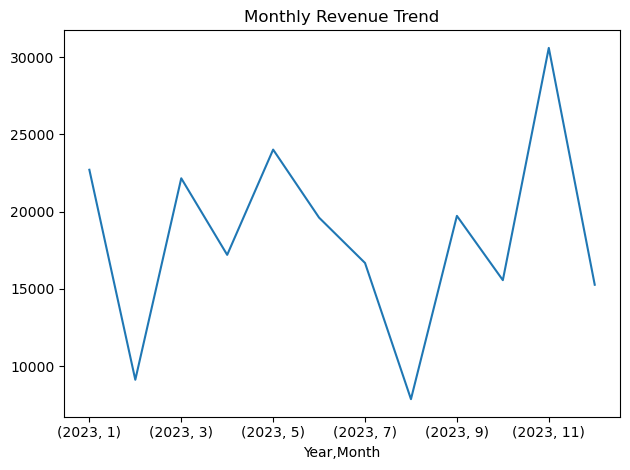

In [3]:
monthly_revenue = df.groupby(["Year","Month"])["Revenue"].sum()

plt.figure()
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.tight_layout()
plt.savefig("monthly_revenue_trend.png")
plt.show()


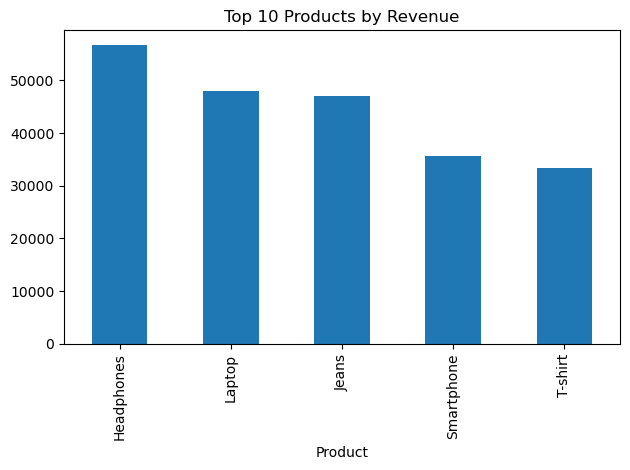

In [4]:
top_products = df.groupby("Product")["Revenue"].sum().sort_values(ascending=False).head(10)

plt.figure()
top_products.plot(kind="bar")
plt.title("Top 10 Products by Revenue")
plt.tight_layout()
plt.savefig("top_products.png")
plt.show()


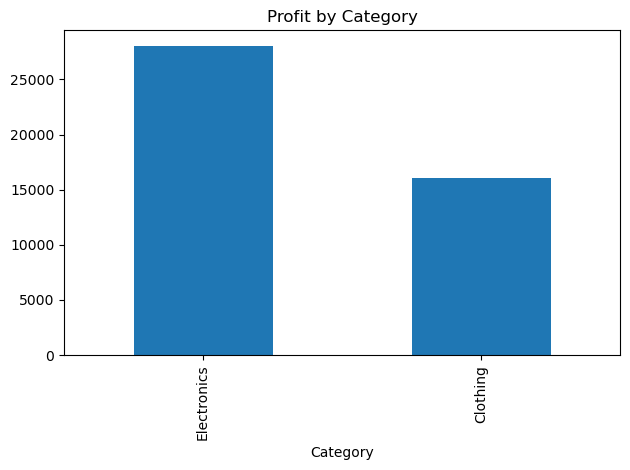

In [5]:
category_profit = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

plt.figure()
category_profit.plot(kind="bar")
plt.title("Profit by Category")
plt.tight_layout()
plt.savefig("category_profit.png")
plt.show()


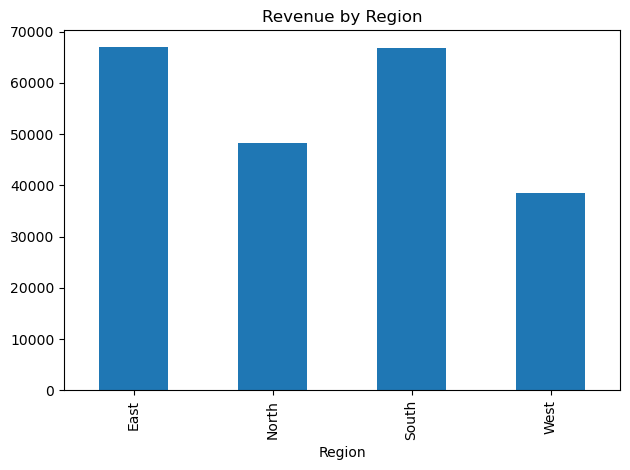

In [6]:
region_revenue = df.groupby("Region")["Revenue"].sum()

plt.figure()
region_revenue.plot(kind="bar")
plt.title("Revenue by Region")
plt.tight_layout()
plt.savefig("region_revenue.png")
plt.show()


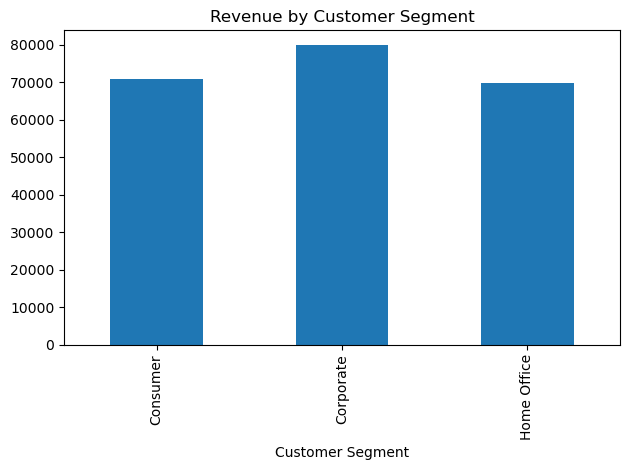

In [7]:
segment_revenue = df.groupby("Customer Segment")["Revenue"].sum()

plt.figure()
segment_revenue.plot(kind="bar")
plt.title("Revenue by Customer Segment")
plt.tight_layout()
plt.savefig("segment_revenue.png")
plt.show()


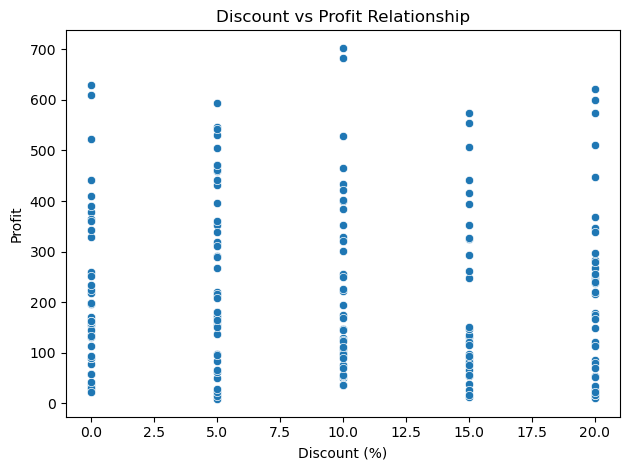

In [8]:
plt.figure()
sns.scatterplot(x="Discount (%)", y="Profit", data=df)
plt.title("Discount vs Profit Relationship")
plt.tight_layout()
plt.savefig("discount_vs_profit.png")
plt.show()


Key Findings

Revenue is concentrated in top-performing regions, suggesting targeted marketing expansion.

A small group of products drives majority of revenue (Pareto effect).

Higher discounts negatively impact profit margins.

Certain customer segments contribute more consistently to revenue.

Seasonal peaks suggest inventory planning opportunities.